### Binary Classification of Consumer Behavior: A Logistic Regression approach on Social Media Ad Conversion


dataset location: ``https://www.kaggle.com/datasets/rakeshrau/social-network-ads?resource=download``

* Name: Jose Aries E. De Los Santos
* Lecturer 2 - Institute of Mathematics
* College of Science, University of the Philippines Diliman

# Import Necessary Libraries

In [1]:
import pandas as pd
import torch
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchmetrics.classification import ConfusionMatrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load and read the data

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
print(f"Features of a dataset: {df.columns}")

Features of a dataset: Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [3]:
display(df)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


# Exploratory Data Analysis (EDA)

Before training our Logistic Regression model, we need to understand the relationship between our features and the target variable (`Purchased`).

### Key Questions:
1. **Class Balance**: Is the dataset balanced, or do we have significantly more non-purchasers?
2. **Feature Distribution**: How do Age and Salary differ for people who purchased vs. those who didn't?
3. **Correlation**: Is there a strong linear relationship between the predictors?

---

## Class Balance

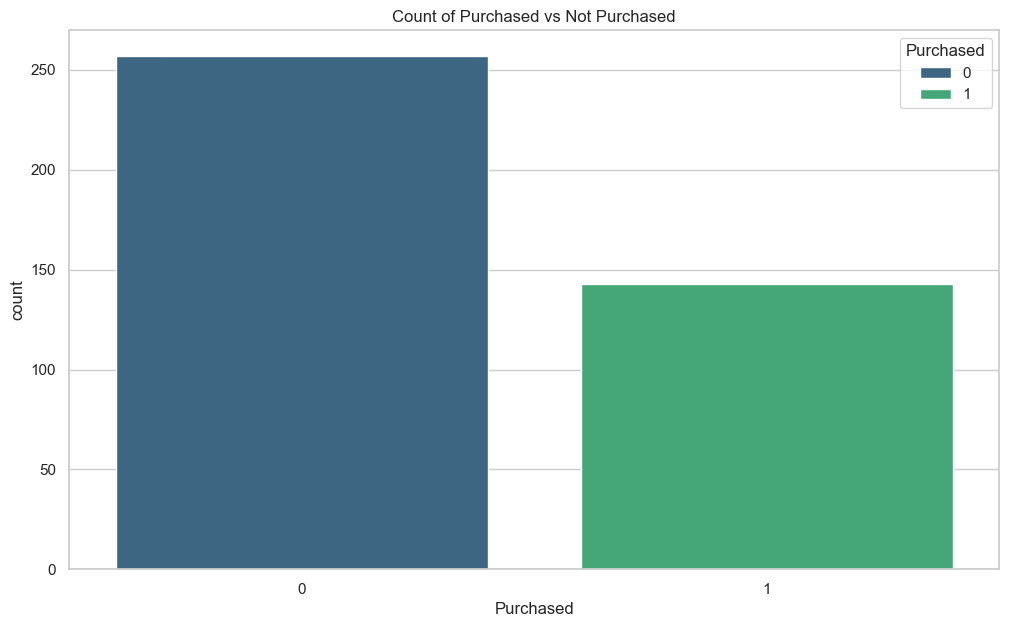

In [4]:
# Set the visual style
sns.set_theme(style="whitegrid")

# 1. Check Class Balance (Updated to avoid FutureWarning)
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Purchased', hue='Purchased', palette='viridis', legend=True)
plt.title('Count of Purchased vs Not Purchased')
plt.show()

## Feature Distribution

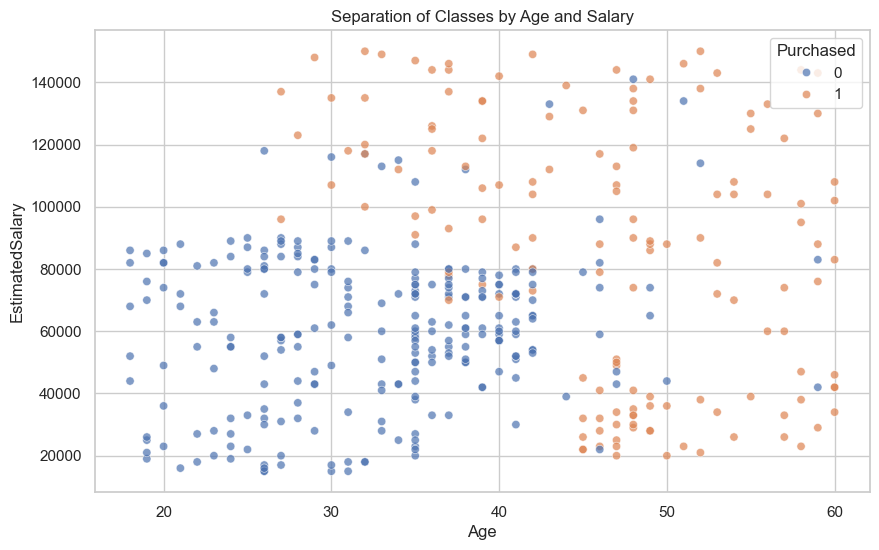

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased', alpha=0.7)
plt.title('Separation of Classes by Age and Salary')
plt.legend(title='Purchased', loc='upper right')
plt.show()


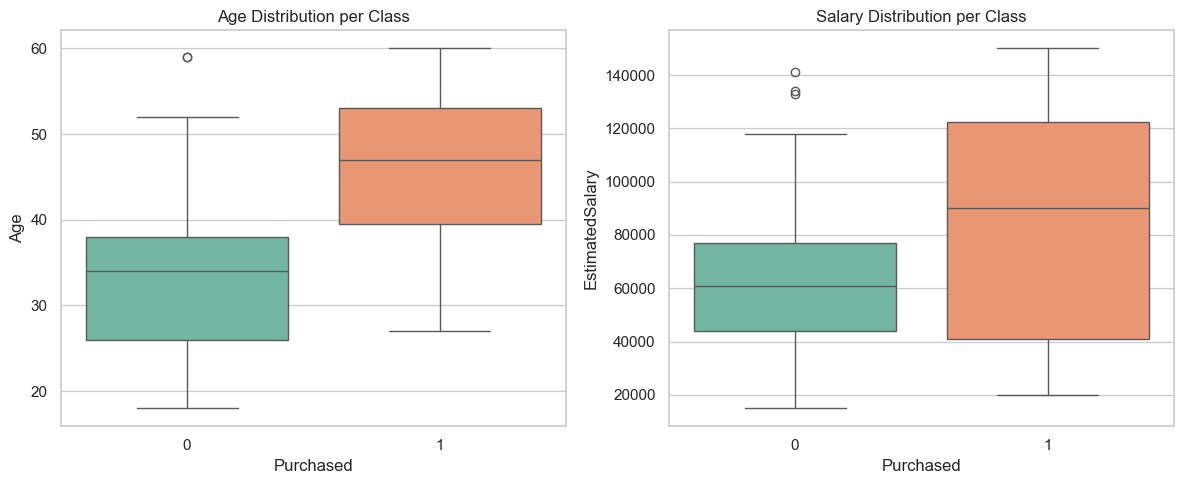

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], data=df, x='Purchased', y='Age', hue='Purchased', palette='Set2', legend=False)
axes[0].set_title('Age Distribution per Class')

sns.boxplot(ax=axes[1], data=df, x='Purchased', y='EstimatedSalary', hue='Purchased', palette='Set2', legend=False)
axes[1].set_title('Salary Distribution per Class')

plt.tight_layout()
plt.show()

# Data Preprocessing Step

## Acquire the Features and Split the data

In [7]:
X = df[["Age", "EstimatedSalary"]].values
y = df[["Purchased"]].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## Normalize the dataset

In [8]:
scalerX = StandardScaler()
X_train_scaled = scalerX.fit_transform(X_train)
X_test_scaled = scalerX.transform(X_test)

## Convert NumPy Arrays to tensors

In [9]:
X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_test_tensor = torch.from_numpy(X_test_scaled).float()

# Labels need to be reshaped from (N,) to (N, 1)
y_train_tensor = torch.from_numpy(y_train).float().view(-1, 1)
y_test_tensor = torch.from_numpy(y_test).float().view(-1, 1)

print(f"X_train shape: {X_train_tensor.shape}") # Should be [300, 2]
print(f"y_train shape: {y_train_tensor.shape}") # Should be [300, 1]
print(f"X_test shape: {X_test_tensor.shape}")   # Should be [100, 2]
print(f"y_test shape: {y_test_tensor.shape}")   # Should be [100

X_train shape: torch.Size([280, 2])
y_train shape: torch.Size([280, 1])
X_test shape: torch.Size([120, 2])
y_test shape: torch.Size([120, 1])


# Logistic Regression Analysis: Social Media Ads

 1. The Logistic Regression Model:

The model predicts the probability of a **Purchase** ($t=1$) given the customer's features $\mathbf{x}$. For the Social Media Ads dataset, the linear predictor $\hat{y}$ (often called the *logit* or *z-score*) is defined as:

$$\hat{y} = w_0 + w_1(\text{Age}) + w_2(\text{EstimatedSalary})$$

---

 2. The Sigmoid (Activation) Function
To turn the linear output $\hat{y}$ (which can be any real number) into a probability $y$ between 0 and 1, we use the **Logistic Sigmoid Function** $\sigma(\cdot)$:

$$P(\text{Purchase}=1 | \mathbf{x}) = y = \sigma(\hat{y}) = \frac{1}{1 + e^{-\hat{y}}}$$






**Mathematical Property: The Derivative**
The derivative of this function (using the quotient rule for derivatives), which is used for optimization, is:
$$\frac{d}{da}(\sigma(a)) = \frac{d}{da}\left(\frac{1}{1+e^{-a}}\right) = \frac{-e^{-a}}{(1 + e^{-a})^{2}} = \left(\frac{1}{1+e^{-a}}\right)\left(1 - \frac{1}{1 + e^{-a}}\right) = \sigma(a)(1 - \sigma(a))$$

---

3. **The Objective Function: Binary Cross-Entropy**
To find the optimal weights $\mathbf{w}$, we minimize the **Cross-Entropy Error function** ($E(\mathbf{w})$). This function penalizes the model more heavily when it is "confidently wrong."

$$E(\mathbf{w}) = -\sum_{n=1}^{N} \{ y_n \ln \hat{y}_{n} + (y - t_n) \ln(1 - \hat{y}_{n}) \}$$

**Where:**
* **$N$**: Total number of observations.
* **$y_n$**: The actual label ($1$ for Purchase, $0$ for No Purchase).
* **$\hat{y}_n$**: The predicted probability from the sigmoid function.


## Create the Sigmoid Function

$$\sigma(\hat{y}) = \frac{1}{1 + e^{-\hat{y}}}$$

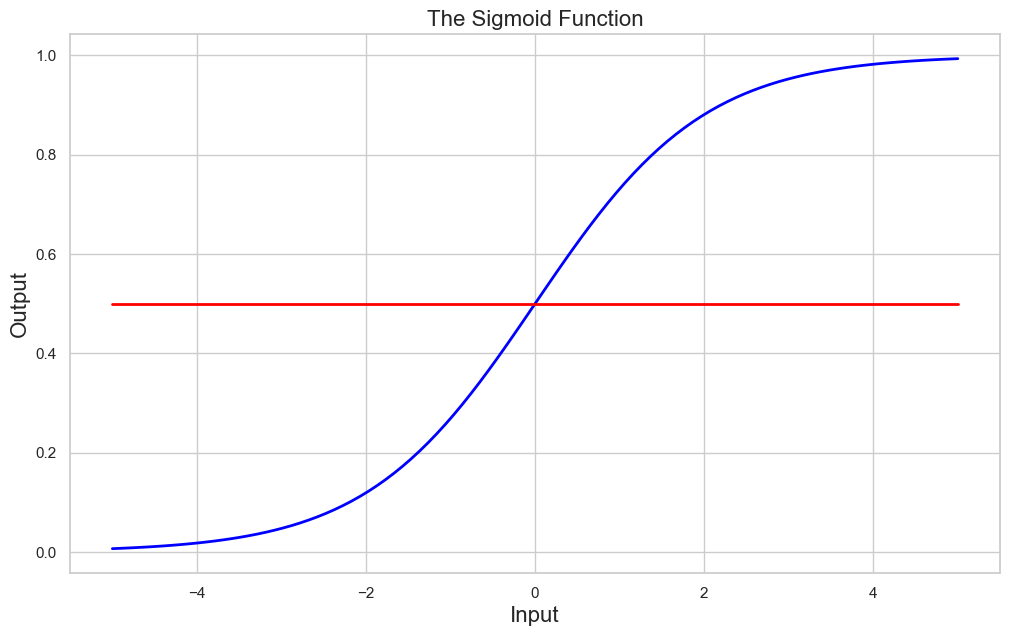

In [10]:
def MySigmoid(y):
    '''
    Implements the Sigmoid Function
    '''
    output = 1 / (1 + torch.exp(-y))
    return output


x = torch.linspace(-5,5,100)
plt.figure(figsize=(12,7))
plt.plot(x.numpy(), MySigmoid(x).numpy(), linewidth=2.0, color="#0000FF", label="Sigmoid")
plt.plot(x.numpy(), jnp.full_like(x.numpy(), 0.5), linewidth=2.0, color="#FF0000")
plt.title("The Sigmoid Function", fontsize=16)
plt.xlabel('Input', fontsize=16)
plt.ylabel('Output', fontsize=16)
plt.show()



## Create the Binary Cross Entropy

$$
\mathcal{L} (\hat{y},y_{true}) = -\sum_{n=1}^{N} \{ y_n \ln \hat{y}_{n} + (y - t_n) \ln(1 - \hat{y}_{n}) \}
$$


* **GOAL** minimize the error between $\hat{y}$ and $,y_{true}$

In [11]:
def binary_cross_entropy(y_pred, y_true):
    epsilon = 1e-15 
    y_pred = torch.clamp(y_pred, epsilon, 1.0 - epsilon)
    
    # The BCE formula
    loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    
    # Return the mean loss for the whole batch
    return torch.mean(loss)

In [12]:
class LogisticRegressionModel(torch.nn.Module):
    '''Implements Logsitic Regression Model using PyTorch'''
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        # Represents w1(Age) + w2(Salary) + w0(bias)
        self.linear = torch.nn.Linear(input_dim, 1)
        
    def forward(self, x):
        # 1. Calculate the linear predictor (logit)
        y_linear = self.linear(x)
        
        # 2. Apply your manual sigmoid activation
        y_prob = MySigmoid(y_linear)
        
        return y_prob

input_size = 2 # Age and Salary
model = LogisticRegressionModel(input_size)

#Loss and Optimizer
##built-in loss function
# criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-2)

# 1. Initialize lists for both
train_loss_history = []
test_loss_history = []

epochs = 1500

for epoch in tqdm(range(epochs)):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    y_pred_train = model(X_train_tensor)
    train_loss = binary_cross_entropy(y_pred_train, y_train_tensor)
    
    # Optimization steps
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    # --- TESTING PHASE ---
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        y_pred_test = model(X_test_tensor)
        test_loss = binary_cross_entropy(y_pred_test, y_test_tensor)
    
    # 2. Append both values
    train_loss_history.append(train_loss.item())
    test_loss_history.append(test_loss.item())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}] | Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}')

  0%|          | 0/1500 [00:00<?, ?it/s]

Epoch [100] | Train Loss: 0.4914 | Test Loss: 0.5161
Epoch [200] | Train Loss: 0.4582 | Test Loss: 0.4877
Epoch [300] | Train Loss: 0.4355 | Test Loss: 0.4679
Epoch [400] | Train Loss: 0.4191 | Test Loss: 0.4535
Epoch [500] | Train Loss: 0.4068 | Test Loss: 0.4426
Epoch [600] | Train Loss: 0.3973 | Test Loss: 0.4341
Epoch [700] | Train Loss: 0.3897 | Test Loss: 0.4273
Epoch [800] | Train Loss: 0.3837 | Test Loss: 0.4218
Epoch [900] | Train Loss: 0.3787 | Test Loss: 0.4172
Epoch [1000] | Train Loss: 0.3745 | Test Loss: 0.4134
Epoch [1100] | Train Loss: 0.3710 | Test Loss: 0.4102
Epoch [1200] | Train Loss: 0.3680 | Test Loss: 0.4074
Epoch [1300] | Train Loss: 0.3654 | Test Loss: 0.4050
Epoch [1400] | Train Loss: 0.3632 | Test Loss: 0.4029
Epoch [1500] | Train Loss: 0.3613 | Test Loss: 0.4011


## Extract Trained weights

In [13]:
# Extract weights and bias
weights = model.linear.weight.detach().numpy()[0]
bias = model.linear.bias.detach().item()

print(f"Weight for Age: {weights[0]:.4f}")
print(f"Weight for Salary: {weights[1]:.4f}")
print(f"Bias (w0): {bias:.4f}")

Weight for Age: 1.4605
Weight for Salary: 0.8305
Bias (w0): -0.7406


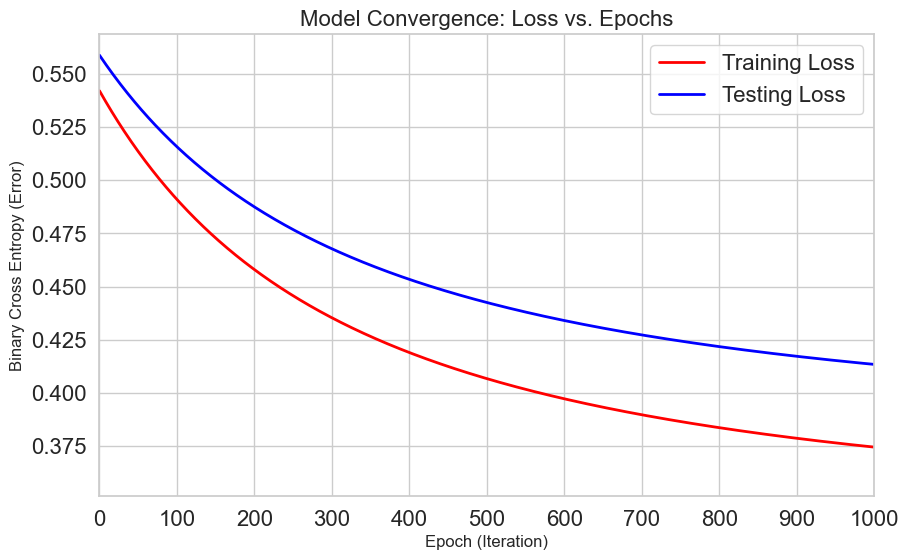

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss', color='#FF0000', linewidth=2.0)
plt.plot(test_loss_history, label='Testing Loss', color='#0000FF', linewidth=2.0)
plt.title("Model Convergence: Loss vs. Epochs", fontsize=16)
plt.xlim(0,1000)
xticks = np.arange(0,1100,100)
plt.xticks(xticks, fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Epoch (Iteration)", fontsize=12)
plt.ylabel("Binary Cross Entropy (Error)", fontsize=12)
plt.grid(True)
plt.legend(loc="upper right", fontsize=16)
plt.show()

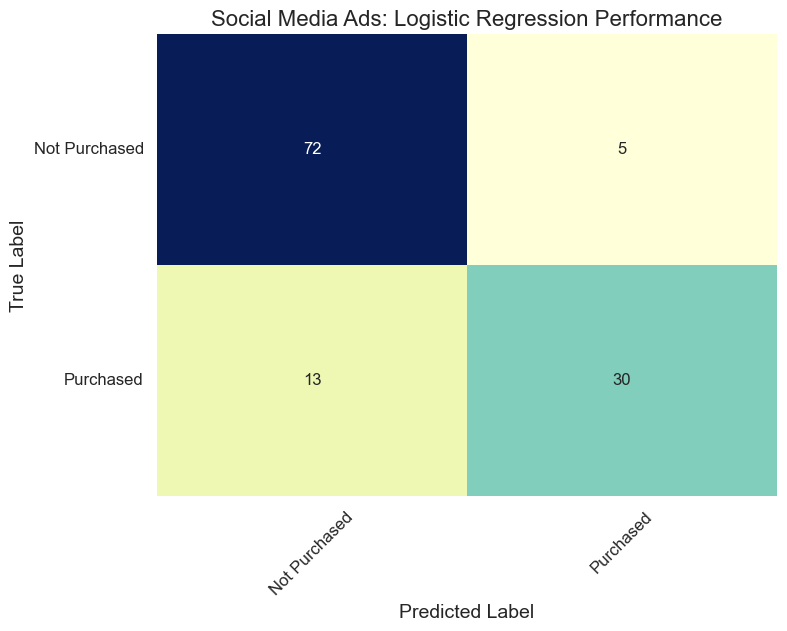

In [15]:
def create_confusion_matrix(y_true, y_pred, 
                            class_names, 
                            num_classes=None, 
                            figsize=(8, 6), 
                            filename=None,
                            figure_title=None):
    
    if num_classes is None:
        num_classes = len(class_names)
    
    # Use "binary" task since we only have 2 classes (Purchased vs Not)
    # This matches the ConfusionMatrix API requirements
    confmat = ConfusionMatrix(num_classes=num_classes, task="binary")
    confmat_tensor = confmat(preds=y_pred, target=y_true)
    
    plt.figure(figsize=figsize)
    sns.heatmap(confmat_tensor.numpy(), 
                annot=True, 
                fmt='d', 
                cmap="YlGnBu", 
                xticklabels=class_names, 
                yticklabels=class_names,
                cbar=False)
    
    if figure_title is not None:
        plt.title(figure_title, fontsize=16)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# --- EXECUTION ---

model.eval()
with torch.no_grad():
    # Get raw probabilities from model
    y_probs = model(X_test_tensor)
    
    # Convert probabilities to discrete 0 or 1 labels
    # We use .int() to ensure they are the correct type for torchmetrics
    y_preds = (y_probs >= 0.5).int().view(-1)
    
    # Ensure actual labels are also 1D integer tensors
    y_true = y_test_tensor.int().view(-1)

#Call your function
create_confusion_matrix(
    y_true=y_true, 
    y_pred=y_preds, 
    class_names=['Not Purchased', 'Purchased'],
    figure_title="Social Media Ads: Logistic Regression Performance"
)

# Model Evaluation Metrics: Understanding the Mistakes

To evaluate our Logistic Regression model, we don't just look at **Accuracy**. We need to understand the trade-offs between different types of errors, especially given the "narrow" salary distribution we observed earlier.

---

**The Confusion Matrix Logic**
The names of the metrics follow a simple rule: **[Verdict] [Model's Guess]**.

* **False Positive (Type I Error):** The model predicted **Positive** (Purchase), but that guess was **False** (Reality was No Purchase). 
    * *Business Impact:* Wasted ad spend on a user who won't buy.
* **False Negative (Type II Error):** The model predicted **Negative** (No Purchase), but that guess was **False** (Reality was an Actual Purchase).
    * *Business Impact:* Lost revenue from a missed sale.

| Term | Model Prediction | Actual Reality |
| :--- | :--- | :--- |
| **True Positive (TP)** | 1 (Purchase) | 1 (Purchase) |
| **True Negative (TN)** | 0 (No Purchase) | 0 (No Purchase) |
| **False Positive (FP)** | 1 (Purchase) | 0 (No Purchase) |
| **False Negative (FN)** | 0 (No Purchase) | 1 (Purchase) |

---

**Key Performance Indicators (KPIs)**

**Precision (Quality)**
Precision measures how "trustworthy" the model is when it predicts a purchase. 
$$\text{Precision} = \frac{TP}{TP + FP}$$
* **Goal:** Minimize **False Positives** (Reduce wasted ad spend).
Recall (Quantity / Sensitivity)
Recall measures the model's ability to find all potential buyers in the dataset.
$$\text{Recall} = \frac{TP}{TP + FN}$$
* **Goal:** Minimize **False Negatives** (Don't miss out on sales).

**F1-Score (The Balance)**
The F1-Score is the harmonic mean of Precision and Recall. It is the best metric to use if you want a balance between minimizing both False Positives and False Negatives.
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

---

**The Threshold Decision**
By default, we use a **0.5 Threshold** on our Sigmoid output. However:
* **To favor Precision:** Raise the threshold (e.g., **0.7**). The model becomes "pickier" and reduces False Positives.
* **To favor Recall:** Lower the threshold (e.g., **0.3**). The model becomes "aggressive" and reduces False Negatives.

In [53]:
model.eval()
with torch.inference_mode():
    test_outputs = model(X_test_tensor)
    y_predicted_classes = test_outputs.round().numpy()
    y_actual = y_test_tensor.numpy()

accuracy = accuracy_score(y_actual, y_predicted_classes)

print(f"Test Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_actual, y_predicted_classes))

Test Accuracy: 84.17%

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.92      0.88        77
         1.0       0.83      0.70      0.76        43

    accuracy                           0.84       120
   macro avg       0.84      0.81      0.82       120
weighted avg       0.84      0.84      0.84       120

